In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
import numpy as np
import pandas as pd

In [70]:
data =  'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [71]:
# !wget $data

In [72]:
df = pd.read_csv(data)
df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [73]:
df.columns


Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='str')

In [74]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [75]:
cols = list(df.dtypes[df.dtypes == 'str'].index)

In [76]:
for c in cols:
    df[c] = df[c].str.lower().str.replace(' ', '_')


In [77]:
df.drivetrain

0         all-wheel_drive
1       front-wheel_drive
2       front-wheel_drive
3         all-wheel_drive
4         all-wheel_drive
              ...        
9699    front-wheel_drive
9700      all-wheel_drive
9701      all-wheel_drive
9702    front-wheel_drive
9703      all-wheel_drive
Name: drivetrain, Length: 9704, dtype: str

In [78]:
df.dtypes.isnull()

engine_displacement    False
num_cylinders          False
horsepower             False
vehicle_weight         False
acceleration           False
model_year             False
origin                 False
fuel_type              False
drivetrain             False
num_doors              False
fuel_efficiency_mpg    False
dtype: bool

In [79]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [80]:
df.horsepower.median()

np.float64(149.0)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

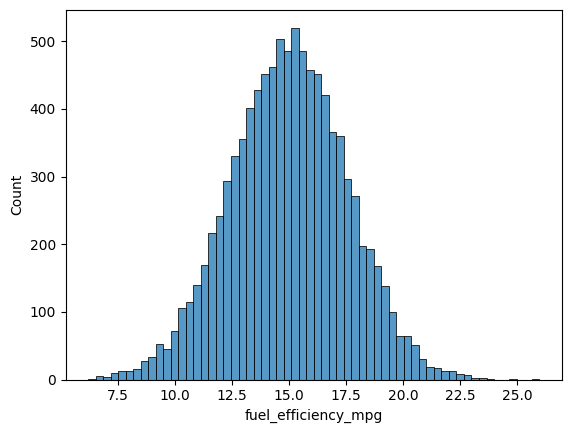

In [81]:
sns.histplot(df.fuel_efficiency_mpg, bins = 60)

In [82]:
new_fuel_eff = np.log1p(df.fuel_efficiency_mpg)

new_fuel_eff


0       2.655474
1       2.687046
2       2.724340
3       2.885512
4       2.601828
          ...   
9699    2.778931
9700    2.942454
9701    2.900684
9702    2.793099
9703    2.765342
Name: fuel_efficiency_mpg, Length: 9704, dtype: float64

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

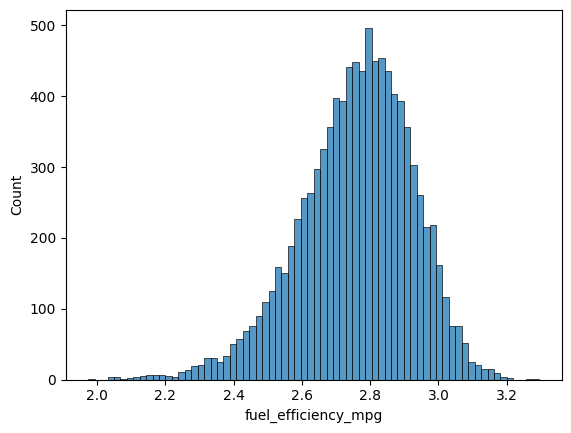

In [83]:
sns.histplot(new_fuel_eff, bins=70)

In [84]:
n = len(df)
n

9704

In [85]:
n_test = int(0.2 * n)
n_val = int(0.2 * n)
n_train = n - n_test - n_val
n_train, n_test, n_val

(5824, 1940, 1940)

In [86]:
idx = np.arange(n)

np.random.seed(42)
np.random.shuffle(idx)
np.array(idx)

array([ 483, 7506, 8795, ..., 5390,  860, 7270], shape=(9704,))

In [87]:
df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train:n_train+n_test]]
df_val = df.iloc[idx[n_train+n_test:]]
df_train


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,usa,gasoline,all-wheel_drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,asia,diesel,front-wheel_drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,asia,diesel,front-wheel_drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,usa,gasoline,all-wheel_drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,usa,gasoline,all-wheel_drive,NaN,19.402209
...,...,...,...,...,...,...,...,...,...,...,...
1696,260,5.0,139.0,2606.972984,15.9,2009,usa,gasoline,all-wheel_drive,-1.0,16.964054
5685,280,4.0,132.0,4004.214323,12.8,2014,europe,diesel,front-wheel_drive,2.0,10.059094
6735,210,3.0,152.0,2500.175687,16.4,2020,europe,gasoline,front-wheel_drive,0.0,17.593237
2052,250,6.0,154.0,2254.313245,13.3,2002,asia,gasoline,front-wheel_drive,2.0,18.925748


In [ ]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
y_train

array([16.64294342, 16.29837715, 18.59182197, ..., 17.59323665,
       18.92574819, 17.96528447], shape=(5824,))

In [89]:
del df_val['fuel_efficiency_mpg']
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_train.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors              float64
dtype: object

In [90]:
len(df_test), len(df_train), len(df_val)

(1940, 5824, 1940)

In [91]:
base = ['horsepower', 'engine_displacement', 'vehicle_weight']

In [92]:
df.model_year.max()

np.int64(2023)

In [93]:
df_train[base].isnull().sum()

horsepower             429
engine_displacement      0
vehicle_weight           0
dtype: int64

### Model

In [ ]:
def get_w (x, y):
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])
    xTx = x.T.dot(x)
    xTx_inv = np.linalg.inv(xTx)
    w = xTx_inv.dot(x.T).dot(y)
    return w[0], w[1:]


In [95]:
x = np.array([[1, 2, 3], [4, 5, 6]])
x

array([[1, 2, 3],
       [4, 5, 6]])

In [96]:
one = np.ones(x.shape[0])
one

array([1., 1.])

In [97]:
x = np.column_stack([one, x])
x

array([[1., 1., 2., 3.],
       [1., 4., 5., 6.]])

In [98]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [99]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight']

In [100]:
df_train[base].isnull().sum()

engine_displacement      0
horsepower             429
vehicle_weight           0
dtype: int64

In [101]:
def prep_x(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [102]:
mean_eff = (df_train.horsepower.mean())
mean_eff

np.float64(149.54476367006487)

In [103]:
def prep_x1(df, m):
    df_num = df[base]
    df_num = df_num.fillna(m)
    x = df_num.values
    return x

In [104]:
def rmse(y, y_pred):
    se = (y-y_pred)**2
    mse = se.mean()
    return np.sqrt(mse)

In [135]:
x_train = prep_x(df_train)
w0, w = get_w(x_train, y_train)

x_val = prep_x(df_val)
y_pred = w0 + x_val.dot(w)
e = rmse(y_val, y_pred)
round(e, 7)



np.float64(0.5165186)

In [106]:
x_train = prep_x1(df_train, mean_eff)
w0, w = get_w(x_train, y_train)

x_val = prep_x1(df_val, mean_eff)
y_pred = w0 + x_val.dot(w)
e = rmse(y_val, y_pred)
round(e, 2)

np.float64(0.46)

<Axes: ylabel='Count'>

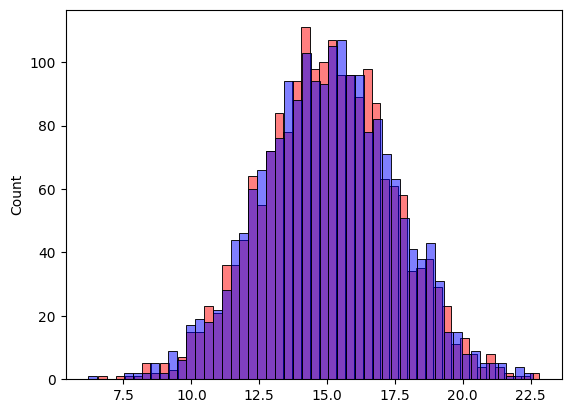

In [107]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## regularization:

In [108]:
base

['engine_displacement', 'horsepower', 'vehicle_weight']

In [109]:
df.model_year.max()

np.int64(2023)

In [110]:
def prep_x2(df):
    df = df.copy()
    df['age'] = 2023 - df.model_year
    features = ['age'] + base
    df_num = df[features]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [ ]:
x_train = prep_x2(df_train)
w0, w = get_w(x_train, y_train)

x_val = prep_x2(df_val)
y_pred = w0 + x_val.dot(w)
e = rmse(y_val, y_pred)
round(e, 7)


np.float64(0.5165004)

<Axes: ylabel='Count'>

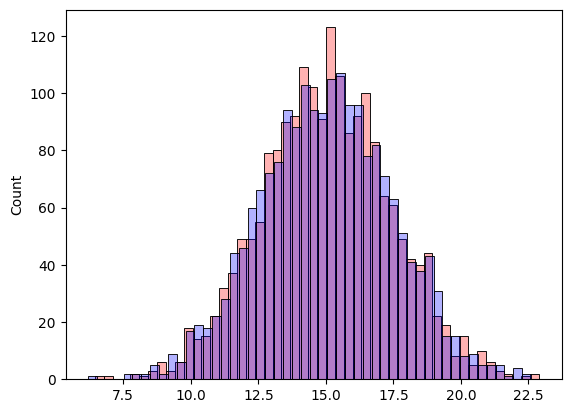

In [112]:
sns.histplot(y_pred, color='red', alpha=0.3, bins=50)
sns.histplot(y_val, color='blue', alpha=0.3, bins=50)

In [113]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [172]:
def get_w_reg(x, y, r=0):
    one = np.ones(x.shape[0])
    x = np.column_stack([one, x])
    xTx = x.T.dot(x)
    xTx = xTx + r*np.eye(xTx.shape[0])

    xTx_inv = np.linalg.inv(xTx)
    wf = xTx_inv.dot(x.T).dot(y)
    return wf[0], wf[1:]



In [121]:
reg = [0, 0.01, 0.1, 1, 5, 10, 100]

In [132]:
for r in reg:
    x_train = prep_x2(df_train)
    w0, w = get_w_reg(x_train, y_train, r)

    x_val = prep_x2(df_val)
    y_pred = w0 + x_val.dot(w)
    e = rmse(y_val, y_pred)
    print(round(e, 8))
    

0.51650039
0.51650671
0.51657809
0.51869444
0.5544421
0.63881277
1.99916741


In [133]:
for r in reg:
    x_train = prep_x(df_train)
    w0, w = get_w_reg(x_train, y_train, r)

    x_val = prep_x(df_val)
    y_pred = w0 + x_val.dot(w)
    e = rmse(y_val, y_pred)
    print(round(e, 8))
    

0.51651859
0.51652439
0.51659064
0.5186089
0.5532004
0.63562713
2.00663692


In [166]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
rms=[]
for s in seed:
    
    idx = np.arange(n)
    np.random.seed(s)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_test = df.iloc[idx[n_train:n_train+n_test]]
    df_val = df.iloc[idx[n_train+n_test:]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_val['fuel_efficiency_mpg']
    del df_train['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    x_train = prep_x2(df_train)
    w0, w = get_w(x_train, y_train)

    x_val = prep_x2(df_val)
    y_pred = w0 + x_val.dot(w)
    e = rmse(y_val, y_pred)
    rms.append(round(e, 3))

rms

[np.float64(0.523),
 np.float64(0.529),
 np.float64(0.511),
 np.float64(0.519),
 np.float64(0.532),
 np.float64(0.508),
 np.float64(0.526),
 np.float64(0.512),
 np.float64(0.508),
 np.float64(0.516)]

In [176]:
# rms = np.array(rms)
a = np.std(rms)
print(round(a, 3))

0.008


In [179]:
s = 9
idx = np.arange(n)
np.random.seed(s)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train:n_train+n_test]]
df_val = df.iloc[idx[n_train+n_test:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_val['fuel_efficiency_mpg']
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_final = pd.concat([df_train, df_val])
df_final = df_final.reset_index(drop=True)
y_final = np.concatenate([y_train, y_val])

x_final = prep_x(df_final)
w0, w = get_w_reg(x_final, y_final, 0.001)

x_test = prep_x(df_test)
y_pred = w0 + x_test.dot(w)
e = rmse(y_test, y_pred)
e   

np.float64(0.5130403581348627)